In [1]:
# Delete All Variables
%reset

In [18]:
import csv
import pandas as pd
import numpy as np
import os
import scipy.interpolate
from scipy import signal, interpolate
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
import warnings
import math

In [27]:
##################################################################################
# Definite path and variables
##################################################################################
### Path to file
path = r"C:\Users\Ariel\OneDrive - Delft University of Technology\6-Phenol Oxidation\20260611\RuC_CV_Ads_1_data"
flname = "20260611_RuC_Phenol_ads_all data"
file = path + "\\" + flname + ".csv"

### Path to water file
path_water = r"C:\Users\Ariel\OneDrive - Delft University of Technology\6-Phenol Oxidation\20260609\CaF2_crystal"
flname_water = "water_1000_afterBS_CO2 remove"
file_water = path_water + "\\" + flname_water + ".csv"

### For baseline shift correction
shiftcorr = 'y'
low_bl = 2000
high_bl = 2050
# low_bl = 3800
# high_bl = 3850
shiftcorr2 = 'n'
low_bl_2 = 1400
high_bl_2 = 1500

### For baseline smoothing
smoothing = 'n'
wn_vec = [1000, 1100, 2100, 2500, 3265,3987] 

### For water correction
watercorr = 'n'
low_water = 1700
high_water = 1760
f_sub = np.linspace(-1.5, 1.5, 180)

wn_vec_water = [1154, 1933, 2500, 2708, 3137, 3661, 3790] 
# wn_vec_water = [978, 1154, 1933, 2500, 2708, 3137, 3661, 3790] 

# For averaging data point
avedp = 'y'
ave_pts = 20

# ### For integration
# # NO_min, NO_max = 1945, 1965
# NO_min, NO_max = 1779, 1881
# N2O_min, N2O_max = 2255, 2275
# # NO_min, NO_max = 1945, 1965
# # CO2_min, CO2_max = 2385, 2400
# # CO_min, CO_max = 1982, 2082
# # CH4_min, CH4_max = 1354, 1410
# CH4_min, CH4_max = 2800, 2900
# # N2O_min, N2O_max = 2150, 2264
# # N2O_min, N2O_max = 1219, 1333 # use this when NO+CO



In [24]:
##################################################################################
# Definite function
##################################################################################
def Get_filename(file):
    _file = os.path.basename(file)
    filename,_ = os.path.splitext(_file)
    dirname = os.path.basename(os.path.dirname(file))
    file_dir = os.path.dirname(file)  
    return dirname, filename, file_dir

def dataread(file, delim):
    data = []
    with open(file, newline = '') as f:
        read_rows = csv.reader(f, delimiter = delim)
        for row in read_rows:
            data.append([_row for _row in row if _row != ''])
    data = pd.DataFrame(data)
    return data

def shift_correction(spec, wn, low_bl, high_bl):
    low_bl_pos = np.searchsorted(wn, low_bl, side='left')
    high_bl_pos = np.searchsorted(wn, high_bl, side='left')
    spec_temp = spec[wn[low_bl_pos]:wn[high_bl_pos]]
    spec_blsub = spec - spec_temp.mean()
    return spec_blsub

def smooting(spec, wn, wn_vec):
    wn_vec_new = []
    wn_vec_new_pos = []
    for i in range(0, len(wn_vec)):
        pos_i = np.searchsorted(wn, wn_vec[i], side='left')
        wn_vec_new.append(wn[pos_i])
        wn_vec_new_pos.append(pos_i)
    spec_BL = pd.DataFrame()
    for j in range(0, len(wn_vec_new)):
        spec_BL_j = spec.reset_index(drop=True)[wn_vec_new_pos[j]-3:wn_vec_new_pos[j]+3].mean()
#         spec_BL_j = spec.reset_index(drop=True).iloc[wn_vec_new_pos[j], :]
        spec_BL = pd.concat([spec_BL, spec_BL_j], axis=1)  
    spec_BL_interp = interpolate.pchip_interpolate(wn_vec_new, spec_BL.T, wn)
    spec_BL_interp = pd.DataFrame(spec_BL_interp)
    spec_BL_interp.index = wn
    spec_BL_interp.columns = spec.columns
    spec_smooth = spec - spec_BL_interp
    return spec_smooth, spec_BL_interp

def water_correction(spec, wn, spec_water, f_sub, low_wn, high_wn):
    low_pos = np.searchsorted(wn, low_water, side='left')
    high_pos = np.searchsorted(wn, high_water, side='left')
    spec_water_temp = spec_water[wn[low_pos]:wn[high_pos]]
    spec_temp = spec[wn[low_pos]:wn[high_pos]]
    diffsum = pd.DataFrame()
    for i in range(len(f_sub)):
        diff_i = spec_temp.sub(spec_water_temp * f_sub[i], axis=0)
        diffsum_i = diff_i.sum()
        diffsum = pd.concat([diffsum, diffsum_i], axis=1)
    diffsum = abs(diffsum.T)
    diffsum.index = f_sub
    f_sub_min = diffsum.idxmin(axis=0)
    base = pd.DataFrame(np.ones((len(wn), len(f_sub_min))))
    base.index = wn
    base.columns = spec.columns
    base2 = base.mul(spec_water, axis=0)
    base3 = base2.mul(f_sub_min, axis=1)
    spec_wtcorr = spec - base3
    return spec_wtcorr, diffsum

def average_datapoint(spec, ave_pts):
    ave_pts_fix = math.floor(len(spec.columns) / ave_pts)   
    spec_ave = pd.DataFrame()
    time_vec_ave = []
    for i in range(1, ave_pts_fix+1):
        k = i * ave_pts
        l = k - ave_pts
        spec_ave_temp = spec.iloc[:, l:k].mean(axis=1)
        spec_ave = pd.concat([spec_ave, spec_ave_temp], axis=1)
        time_vec = spec.columns
        time_temp = time_vec[l+ave_pts-1]
        time_vec_ave.append(time_temp)
    if len(spec.columns) % ave_pts == 1:
        spec_ave = pd.concat([spec_ave, spec.iloc[:, -1]], axis=1)
        time_vec_ave.append(time_vec[-1])
    elif len(spec.columns) % ave_pts == 2:
        spec_ave = pd.concat([spec_ave, spec.iloc[:, -2:]], axis=1)
        time_vec_ave.append(time_vec[-2:])
    spec_ave.columns = time_vec_ave
    return spec_ave

def trapint(spec, wn, start_idx, end_idx):
    area = 0
    for k in range(start_idx, end_idx):
        xa = wn.values[k]
        xb = wn.values[k+1]
        ya = spec.values[k]
        yb = spec.values[k+1]
        if xa < xb:
            trapezoid_k = (xb - xa) * (ya + yb) / 2
        else:
            trapezoid_k = (xa - xb) * (ya + yb) / 2
        area = area + trapezoid_k
    return area

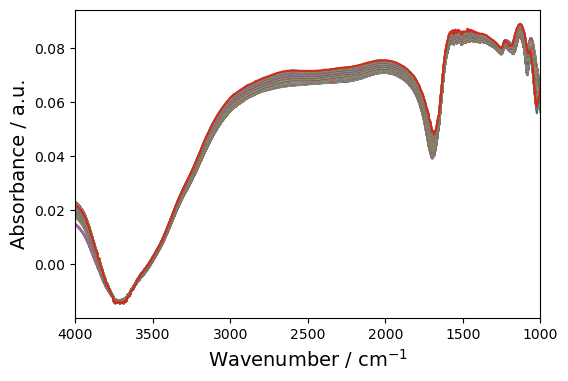

In [25]:
##################################################################################
# Read data
##################################################################################
dirname, filename, file_dir = Get_filename(file)
data = dataread(file, ',')

wn = data.loc[1:, 0].astype(np.float64)
time_vec = data.loc[0, 1:].astype(np.float64)

spec_org = data.loc[1:, 1:].astype(np.float64)
spec_org = pd.DataFrame(spec_org)
spec_org.index = wn
spec_org.columns = time_vec

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()
# for i in range(1, len(spec_org.columns)):
for i in range(len(spec_org.columns)):
    ax.plot(wn, spec_org.iloc[:, i])
ax.set_xlim(4000, 1000)
# ax.set_ylim()
ax.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
ax.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")
plt.show()

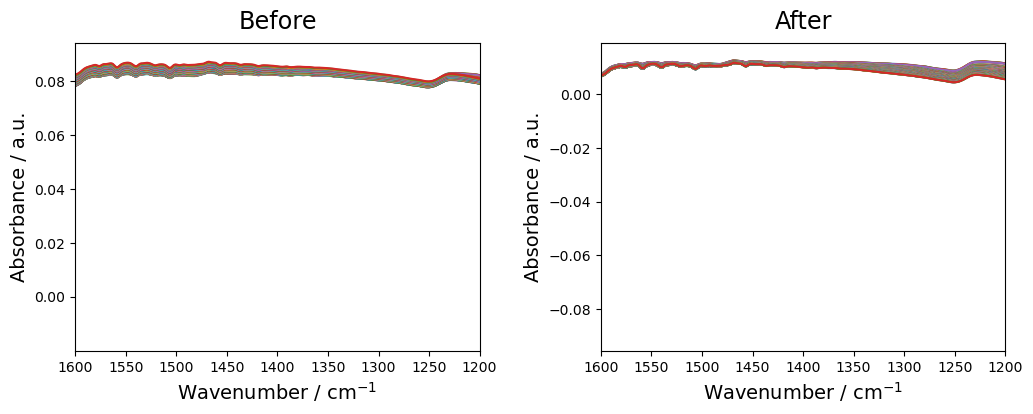

In [30]:
##################################################################################
# Baseline shift correction
##################################################################################
if shiftcorr == 'y':
    spec_blsub = shift_correction(spec_org, wn, low_bl, high_bl)
    
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    
    for i in range(len(spec_org.columns)): 
 
        ax1.plot(wn, spec_org.iloc[:, i])
        ax2.plot(wn, spec_blsub.iloc[:, i])
        
    ax1.set_xlim(1600, 1200)
    # ax1.set_ylim(-0.0005, 0.2)
    ax1.set_title("Before", pad=10, fontsize='xx-large')
    ax1.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
    ax1.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")
    
    ax2.set_xlim(1600, 1200)
    # ax2.set_ylim(-0.005, 0.04)
    ax2.set_title("After", pad=10, fontsize='xx-large')
    ax2.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
    ax2.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")
    
    plt.show()
else:
    spec_blsub = spec_ave

In [8]:
# file_export = r"C:/Users/Ariel/surfdrive/3rd year/Joy_BEP/Joy/20240527/Cu_KNO3_Cte_V_after BS.csv"
# spec_blsub.to_csv(file_export)

In [6]:
# # ##################################################################################
# # # Plotting after BS
# # ##################################################################################


# wn = data.loc[1:, 0].astype(np.float64)
# time_vec = data.loc[0, 1:].astype(np.float64)
# # time_vec = data.loc[0, 1:]

# spec_org = pd.DataFrame(spec_blsub)
# spec_org.index = wn
# spec_org.columns = time_vec

# # Calculate range to suggest offset
# global_min = spec_org.min().min()
# global_max = spec_org.max().max()
# data_range = global_max - global_min
# print(f"Data range: {data_range}")
# offset_step = data_range * 0.15


# fig = plt.figure(figsize=(6, 4))
# ax = fig.add_subplot()
# # for i in range(1, len(spec_org.columns)):
# for i in range(len(spec_org.columns)):
#     offset = i * offset_step
#     y_data = spec_org.iloc[:, i] + offset
#     ax.plot(wn, y_data)
# ax.set_xlim(2000, 1000)
# # ax.set_ylim(-0.001, 0.001)
# ax.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
# ax.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")
# plt.savefig("Calibration_phenol_Si wafer", dpi=300, bbox_inches='tight')
# plt.show()

In [31]:
##################################################################################
# Baseline smoothing
##################################################################################
if smoothing == 'y':
    spec_smooth, spec_BL_interp = smooting(spec_blsub, wn, wn_vec)
    
    n = [0, 10, 20, 100, 150, 300]

    fig = plt.figure(figsize=(15, 8))
    for i in range(0, len(n)):
        ax_i = fig.add_subplot(2, 3, i+1)
        ax_i.plot(wn, spec_blsub.iloc[:, n[i]])
        ax_i.plot(wn, spec_BL_interp.iloc[:, n[i]])
        ax_i.set_xlim(4000, 800)
        ax_i.set_ylim(-0.005, 0.01)
    
    plt.subplots_adjust(wspace=0.3, hspace=0.2)
    plt.show()
else:
    spec_smooth = spec_blsub

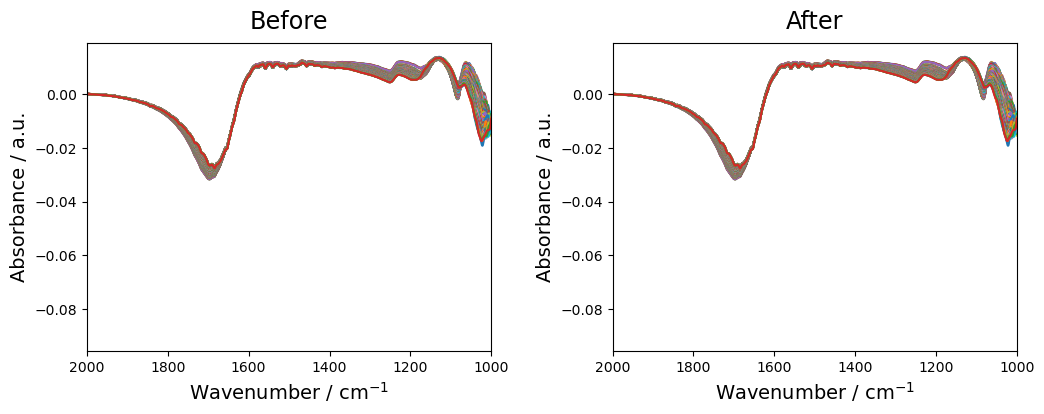

In [32]:
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    
    for i in range(len(spec_smooth.columns)): 
        ax1.plot(wn, spec_blsub.iloc[:, i])
        ax2.plot(wn, spec_smooth.iloc[:, i])
        
    ax1.set_xlim(2000, 1000)
    # ax1.set_ylim(-0.02, 0.2)
    ax1.set_title("Before", pad=10, fontsize='xx-large')
    ax1.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
    ax1.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")
    
    ax2.set_xlim(2000, 1000)
    # ax2.set_ylim(-0.02, 0.2)
    ax2.set_title("After", pad=10, fontsize='xx-large')
    ax2.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
    ax2.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")
    
    plt.show()

In [33]:
##################################################################################
# Water correction
##################################################################################
if watercorr == 'y':
    ### Read Water spectrum and baseline smoothing
    data_water = dataread(file_water, ',')
    spec_water = data_water.loc[1:, 1].astype(np.float64)
    wn_water = data_water.loc[1:, 0].astype(np.float64)
    
    wn_vec_water_new = []
    wn_vec_water_new_pos = []
    for i in range(0, len(wn_vec_water)):
        pos_i = np.searchsorted(wn_water, wn_vec_water[i], side='left')
        wn_vec_water_new.append(wn_water[pos_i])
        wn_vec_water_new_pos.append(pos_i)
    
    spec_water_BL = []
    for j in range(0, len(wn_vec_water_new)):
        spec_water_BL_j = spec_water[wn_vec_water_new_pos[j]-2:wn_vec_water_new_pos[j]+2]
        spec_water_BL.append(spec_water_BL_j.mean())
    
    spec_water_BL_interp = interpolate.pchip_interpolate(wn_vec_water_new, spec_water_BL, wn)
    spec_water_BL_interp = pd.DataFrame(spec_water_BL_interp).iloc[:, 0]
    spec_water_smooth = spec_water.reset_index(drop=True) - spec_water_BL_interp
    spec_water_smooth.index = wn
    

    ### Do correction
    spec_wtcorr, diffsum = water_correction(spec_smooth, wn, spec_water_smooth, f_sub, low_water, high_water)
    
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    ax1.plot(wn, spec_water)
    ax1.plot(wn, spec_water_BL_interp)
    ax1.plot(wn, spec_water_smooth)
    ax1.set_xlim([2400, 1000])
    # ax1.set_ylim([-0.002, 0.005])
    ax1.set_xlabel("Wavenumber [cm^-1]", size = 14, weight = "light")
    ax1.set_ylabel("Absorbance [a.u.]", size = 14, weight = "light")

    for i in range(len(spec_smooth.columns)):
        diffsum_i = diffsum.iloc[:, i]
        ax2.plot(f_sub, diffsum_i)
        ax2.set_xlim([min(f_sub), max(f_sub)])
        ax2.set_xlabel("f_sub", size = 14, weight = "light")
        ax2.set_ylabel("diffsum", size = 14, weight = "light")
    plt.show()
    
else:
    spec_wtcorr = spec_smooth

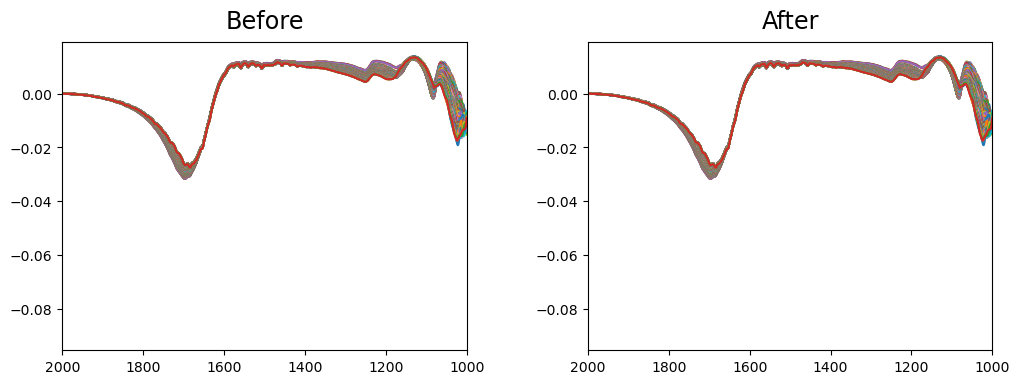

In [34]:
##################################################################################
# Check spectra
##################################################################################
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for i in range(0, len(spec_wtcorr.columns), 1):
    ax1.plot(wn, spec_smooth.iloc[:, i])
#     ax1.plot(wn, spec_blsub.iloc[:, i])
    ax2.plot(wn, spec_wtcorr.iloc[:, i])
    
ax1.set_xlim(2000, 1000)
# ax1.set_ylim(-0.005, 0.09)
ax1.set_title("Before", pad=10, fontsize='xx-large')

ax2.set_xlim(2000, 1000)
# ax2.set_ylim(-0.005, 0.09)
ax2.set_title("After", pad=10, fontsize='xx-large')

plt.show()

Data range: 0.10416985586074726


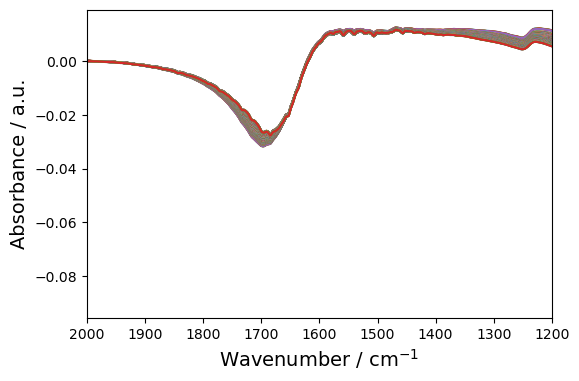

In [35]:
##################################################################################
# Plot after the water substraction
##################################################################################

wn = data.loc[1:, 0].astype(np.float64)
# time_vec = data.loc[0, 1:].astype(np.float64)
time_vec = data.loc[0, 1:]

spec_org = pd.DataFrame(spec_wtcorr)
spec_org.index = wn
spec_org.columns = time_vec

# Calculate range to suggest offset
global_min = spec_org.min().min()
global_max = spec_org.max().max()
data_range = global_max - global_min
print(f"Data range: {data_range}")
offset_step = data_range * 0


fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()
# for i in range(1, len(spec_org.columns)):
for i in range(len(spec_org.columns)):
    offset = i * offset_step
    y_data = spec_org.iloc[:, i] + offset
    ax.plot(wn, y_data)
ax.set_xlim(2000, 1200)
# ax.set_ylim(-0.0008, 0.0008)
ax.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
ax.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")

# plt.savefig("M2-1_2V", dpi=300, bbox_inches='tight')
plt.show()

In [36]:
%matplotlib qt

In [60]:
##################################################################################
# Plot before the averaging data points
##################################################################################

wn = data.loc[1:, 0].astype(np.float64)
# time_vec = data.loc[0, 1:].astype(np.float64)
time_vec_raw = data.loc[0, 1:]
# Convert time_vec to float and remove None values
time_vec = pd.to_numeric(time_vec_raw, errors='coerce')
# Get indices where time values are valid (not NaN)
valid_idx = time_vec.dropna().index
time_vec = time_vec[valid_idx]

spec_org = pd.DataFrame(spec_wtcorr.iloc[:, valid_idx])
spec_org.index = wn
spec_org.columns = time_vec

# Calculate range to suggest offset
global_min = spec_org.min().min()
global_max = spec_org.max().max()
data_range = global_max - global_min
print(f"Data range: {data_range}")
offset_step = data_range * 0


# Colormap choice
cmap_name = "coolwarm"
cmap = plt.get_cmap(cmap_name)

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot()
# for i in range(1, len(spec_org.columns)):
for i in range(len(spec_org.columns)):
    offset = i * offset_step
    y_data = spec_org.iloc[:, i] + offset
    # Get actual time value and normalize it for color mapping
    time_val = float(spec_org.columns[i])
    time_min = float(spec_org.columns[0])
    time_max = float(spec_org.columns[-1])
    normalized_time = (time_val - time_min) / (time_max - time_min)  # Normalize to [0, 1]
    color = cmap(normalized_time)
    ax.plot(wn, y_data, color=color)

# Create colorbar to show time progression
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.2)
# Use actual time values for normalization
time_min = float(spec_org.columns[0])
time_max = float(spec_org.columns[-1])
norm = Normalize(vmin=time_min, vmax=time_max)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
# Set time ticks with actual values
time_ticks = np.linspace(time_min, time_max, 5)
time_labels = [f"{int(t/60):.0f}" for t in time_ticks]
cbar.set_ticks(time_ticks)
cbar.set_ticklabels(time_labels)
cbar.set_label("Time / minute", size=12, weight="light")

ax.set_xlim(4000, 1200)
# ax.set_ylim(0, 0.02)
ax.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
ax.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")

plt.savefig("20260611_RuC_Phenol_ads_all data_full range", dpi=300, bbox_inches='tight')
plt.show()


Data range: 0.10416985586074726


In [61]:
##################################################################################
# Averaging data points
##################################################################################
if avedp == 'y':
    spec_afterdp = average_datapoint(spec_wtcorr, ave_pts)
else:
    spec_afterdp = spec_wtcorr

In [62]:
##################################################################################
# Plot after the averaging data points
##################################################################################

wn = data.loc[1:, 0].astype(np.float64)

# Get time values from spec_afterdp columns (already averaged)
time_vec = pd.to_numeric(spec_afterdp.columns, errors='coerce')

spec_org = pd.DataFrame(spec_afterdp)
spec_org.index = wn
spec_org.columns = time_vec

# Calculate range to suggest offset
global_min = spec_org.min().min()
global_max = spec_org.max().max()
data_range = global_max - global_min
print(f"Data range: {data_range}")
offset_step = data_range * 0

# Colormap choice
cmap_name = "coolwarm"
cmap = plt.get_cmap(cmap_name)

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot()
# for i in range(1, len(spec_org.columns)):
for i in range(len(spec_org.columns)):
    offset = i * offset_step
    y_data = spec_org.iloc[:, i] + offset
    # Get actual time value and normalize it for color mapping
    time_val = float(spec_org.columns[i])
    time_min = float(spec_org.columns[0])
    time_max = float(spec_org.columns[-1])
    normalized_time = (time_val - time_min) / (time_max - time_min)  # Normalize to [0, 1]
    color = cmap(normalized_time)
    ax.plot(wn, y_data, color=color)

# Create colorbar to show time progression
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
# Use actual time values for normalization
time_min = float(spec_org.columns[0])
time_max = float(spec_org.columns[-1])
norm = Normalize(vmin=time_min, vmax=time_max)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
# Set time ticks with actual values converted to minutes
time_ticks = np.linspace(time_min, time_max, 5)
time_labels = [f"{int(t/60)}" for t in time_ticks]  # Convert to minutes
cbar.set_ticks(time_ticks)
cbar.set_ticklabels(time_labels)
cbar.set_label("Time / minute", size=12, weight="light")

ax.set_xlim(4000, 1200)
# ax.set_ylim(0.004, 0.015)
ax.set_xlabel("Wavenumber / cm$^{-1}$", size = 14, weight = "light")
ax.set_ylabel("Absorbance / a.u.", size = 14, weight = "light")

plt.savefig("20260611_RuC_Phenol_ads_averaged_full range", dpi=300, bbox_inches='tight')
plt.show()


Data range: 0.10271284104201872


In [18]:
file_export = r"C:\Users\Ariel\OneDrive - Delft University of Technology\6-Phenol Oxidation\20260611\RuC_CV_Ads_1_data\20260611_RuC_Phenol_ads_OCV_after reaction.csv"
spec_afterdp.to_csv(file_export)